# Electrodynamics → the dispersion operator
### Connecting this repo to Griffiths *Introduction to Electrodynamics* (Ch. 7–9)

The dispersion-assisted Gerchberg–Saxton receiver inverts **one** operator,

$$H(f)=e^{\,i\pi D f^2},$$

a phase that is **quadratic in frequency**. This notebook shows that this operator
is not an ad-hoc choice — it falls straight out of Maxwell's equations:

$$\textbf{Maxwell}\;\to\;\text{wave equation}\;\to\;\text{plane wave }e^{i(kz-\omega t)}
\;\to\;k(\omega)\;\to\;\text{GVD }\beta_2\;\to\;H(f)=e^{i\pi D f^2}.$$

Everything below runs from `griffiths.electrodynamics`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # repo root (notebook runs in notebooks/)
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()

from griffiths import electrodynamics as ed
from dgs import dispersion_gs_prototype as dg
mu, eps, omega, k, z, t = ed.mu, ed.eps, ed.omega, ed.k, ed.z, ed.t
print("loaded griffiths.electrodynamics")

loaded griffiths.electrodynamics


## 1. Maxwell's equations — the source of everything

Two **divergence** laws (where the fields come from) and two **curl** laws
(how they drive each other in time). In a linear medium $D=\varepsilon E$,
$H=B/\mu$.

In [2]:
for name, eq in ed.maxwell_equations().items():
    print(f"{name:10s}:", eq)

Gauss_E   : Eq(div_E, rho/epsilon)
Gauss_B   : Eq(div_B, 0)
Faraday   : Eq(curl_E, -dB/dt)
Ampere    : Eq(curl_B, J*mu + dE/dt*epsilon*mu)


## 2. Maxwell → the 1-D wave equation

Take $E=E(z,t)\,\hat x$, $B=B(z,t)\,\hat y$, no free charge or current.
Faraday and Ampère become two coupled first-order PDEs; cross-differentiate to
eliminate $B$ and the wave equation appears.

Faraday: Eq(Derivative(E(z, t), z), -Derivative(B(z, t), t))
Ampere : Eq(-Derivative(B(z, t), z), epsilon*mu*Derivative(E(z, t), t))


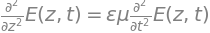

In [3]:
wave, steps = ed.wave_equation_1d()
print("Faraday:", steps['faraday'])
print("Ampere :", steps['ampere'])
wave

## 3. Plane wave + dispersion relation

The complex exponential $E=e^{i(kz-\omega t)}$ solves the wave equation **iff**
$k^2=\mu\varepsilon\,\omega^2$. The electric and magnetic components are locked
together by the **wave impedance** $Z=\sqrt{\mu/\varepsilon}$ (vacuum: $\approx 377\,\Omega$).

In [4]:
disp, k_w, n = ed.plane_wave_dispersion()
print("dispersion relation:", disp)
print("k(omega) =", k_w)
print("refractive index n =", n)
Z0 = ed.wave_impedance(medium=False)
print("vacuum impedance Z0 =", Z0,
      "=", float(Z0.subs({ed.mu0: 4e-7*np.pi, ed.eps0: 8.8541878128e-12})), "ohm")

dispersion relation: Eq(k**2, epsilon*mu*omega**2)
k(omega) = sqrt(epsilon)*sqrt(mu)*omega
refractive index n = sqrt(epsilon)*sqrt(mu)/(sqrt(epsilon_0)*sqrt(mu_0))
vacuum impedance Z0 = sqrt(mu_0)/sqrt(epsilon_0) = 376.7303135643202 ohm


## 4. Ohm's law in tensor form, and *why* media disperse

In an anisotropic medium the conductivity is a **tensor**: $\mathbf J=\sigma\cdot\mathbf E$,
so a field along $x$ can drive a current with a $y$ component. And $\sigma$ depends
on **frequency** (Drude): the electrons cannot follow the field instantly, so
different colours see different $\sigma$ — hence different $k(\omega)$. *That* is
dispersion.

In [5]:
J, Sig = ed.ohms_law_tensor([[sp.Symbol('s_xx'), sp.Symbol('s_xy'), 0],
                               [sp.Symbol('s_yx'), sp.Symbol('s_yy'), 0],
                               [0, 0, sp.Symbol('s_zz')]])
print("sigma ="); sp.pprint(Sig)
print("J = sigma . E ="); sp.pprint(J)
print("Drude sigma(omega) =", ed.drude_conductivity())

sigma =
⎡sₓₓ   s_xy   0  ⎤
⎢                ⎥
⎢s_yx  s_yy   0  ⎥
⎢                ⎥
⎣ 0     0    s_zz⎦
J = sigma . E =
⎡Eₓ⋅sₓₓ + E_y⋅s_xy ⎤
⎢                  ⎥
⎢Eₓ⋅s_yx + E_y⋅s_yy⎥
⎢                  ⎥
⎣     E_z⋅s_zz     ⎦
Drude sigma(omega) = sigma_0/(I*omega*tau + 1)


## 5. Poynting flux and optical power in decibels

A square-law detector measures the time-averaged flux
$\langle S\rangle=E_0^2/(2Z)$ — the **intensity** $I_1,I_2$ the receiver works
from. Optical power is conventionally quoted in **dB** (10·log₁₀ for power).

<S> = E_0**2*sqrt(epsilon)/(2*sqrt(mu))


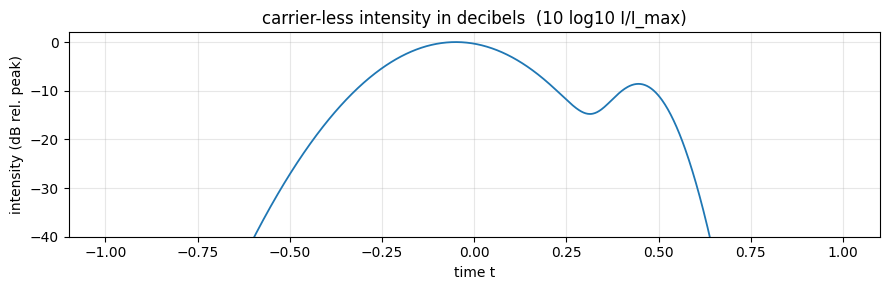

In [6]:
E0 = sp.Symbol('E_0', positive=True)
print("<S> =", ed.time_average_poynting(E0))

t_, x, A, phi = dg.make_field(N=1024, seed=3)
I = np.abs(x)**2
plt.figure(figsize=(9,3))
plt.plot(t_, ed.to_decibels(I, ref=I.max()), lw=1.3)
plt.ylim(-40, 2); plt.xlabel('time t'); plt.ylabel('intensity (dB rel. peak)')
plt.title('carrier-less intensity in decibels  (10 log10 I/I_max)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 6. The bridge — GVD becomes $H(f)=e^{i\pi D f^2}$

Expand $k(\omega)$ about a carrier $\omega_0$:

$$k(\omega)=k_0+\beta_1\,\Delta\omega+\tfrac12\beta_2\,\Delta\omega^2+\cdots$$

- $k_0$ → a constant phase (removable),
- $\beta_1=1/v_g$ → a pure **group delay** (removable by a moving frame),
- $\beta_2=\mathrm d^2k/\mathrm d\omega^2$ → **group-velocity dispersion**, the first
  term that *reshapes* the pulse.

Over length $L$ the residual transfer function is
$\exp\!\big(i\tfrac12\beta_2 L(2\pi f)^2\big)$. Matching to $e^{i\pi D f^2}$ gives
$\boxed{D = 2\pi\,\beta_2 L}$ — and then it is **literally** the repo's `disperse()`.

In [7]:
beta2, L = 1.7, 0.9
D = ed.dispersion_param_D(beta2, L)
f = np.fft.fftfreq(len(x))
H_phys = ed.gvd_transfer(f, beta2, L)         # from Maxwell/GVD
H_repo = np.exp(1j*np.pi*D*f**2)              # the repo's operator
print(f"D = 2*pi*beta2*L = {D:.4f}")
print("max |H_phys - H_repo| =", np.abs(H_phys - H_repo).max(), " (identical)")

# applying the Maxwell-derived operator == dg.disperse(x, D)
xd_phys = np.fft.ifft(np.fft.fft(x) * H_phys)
xd_repo = dg.disperse(x, D)
print("max |propagate_phys - disperse(x,D)| =", np.abs(xd_phys - xd_repo).max())

D = 2*pi*beta2*L = 9.6133
max |H_phys - H_repo| = 1.790180836524724e-15  (identical)
max |propagate_phys - disperse(x,D)| = 1.1857187100668868e-16


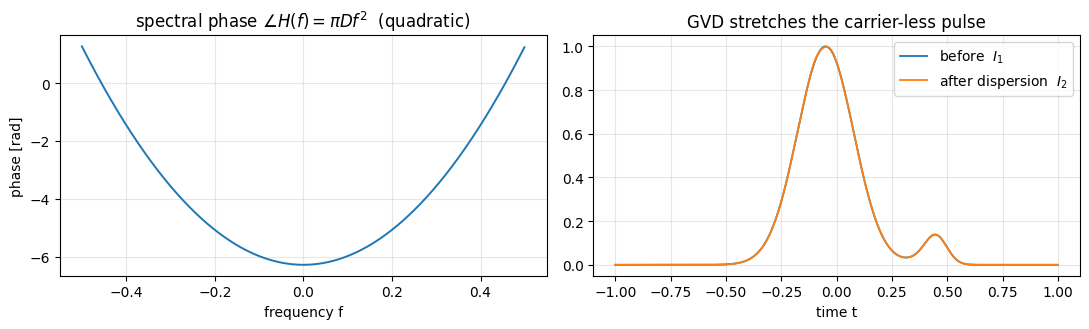

In [8]:
# visualize: the quadratic spectral phase, and the pulse it stretches
fig, ax = plt.subplots(1, 2, figsize=(11,3.4))
order = np.argsort(f)
ax[0].plot(f[order], np.unwrap(np.angle(H_repo[order])), lw=1.4)
ax[0].set_title(r'spectral phase $\angle H(f)=\pi D f^2$  (quadratic)')
ax[0].set_xlabel('frequency f'); ax[0].set_ylabel('phase [rad]'); ax[0].grid(alpha=0.3)
ax[1].plot(t_, np.abs(x)**2, label='before  $I_1$', lw=1.3)
ax[1].plot(t_, np.abs(xd_repo)**2, label='after dispersion  $I_2$', lw=1.3)
ax[1].set_title('GVD stretches the carrier-less pulse'); ax[1].set_xlabel('time t')
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Summary — the repo *is* electrodynamics

| Griffiths / EM | This repo |
|---|---|
| Maxwell's equations | the medium the light propagates in |
| 1-D wave equation | `disperse()` propagates the field |
| plane wave $e^{i(kz-\omega t)}$ | the complex carrier-less field $E(t)=A\,e^{i\phi}$ |
| dispersion relation $k(\omega)$ | which colour is delayed how much |
| GVD $\beta_2$ over length $L$ | the parameter $D=2\pi\beta_2 L$ |
| quadratic spectral phase | $H(f)=e^{i\pi D f^2}$ |
| square-law detector $\langle S\rangle$ | the intensities $I_1,I_2$ |

Gerchberg–Saxton then **inverts** this operator to recover the phase $\phi(t)$ the
detector threw away. Civilian optical metrology / education.